In [16]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

df=pd.read_csv("credit_risk_dataset.csv")
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [18]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [19]:
df[[
    "person_age",
    "person_income",
    "loan_amnt",
    "cb_person_cred_hist_length"
]].describe()


,person_age,person_income,loan_amnt,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000
mean,27.734600,6.607485e+04,9589.371106,5.804211
std,6.348078,6.198312e+04,6322.086646,4.055001
min,20.000000,4.000000e+03,500.000000,2.000000
25%,23.000000,3.850000e+04,5000.000000,3.000000
50%,26.000000,5.500000e+04,8000.000000,4.000000
75%,30.000000,7.920000e+04,12200.000000,8.000000
max,144.000000,6.000000e+06,35000.000000,30.000000


In [20]:
df[[
    "person_emp_length",
    "loan_int_rate"
]].isnull().sum()


person_emp_length     895
loan_int_rate        3116
dtype: int64

In [21]:
df["person_emp_length"].fillna(df["person_emp_length"].median(), inplace=True)
df["loan_int_rate"].fillna(df["loan_int_rate"].median(), inplace=True)


In [22]:
X = df[[
    "person_age",
    "person_income",
    "loan_amnt",
    "cb_person_cred_hist_length",
    "loan_int_rate",
    "loan_percent_income"
]]

X.head()


,person_age,person_income,loan_amnt,cb_person_cred_hist_length,loan_int_rate,loan_percent_income
0,22,59000,35000,3,16.02,0.59
1,21,9600,1000,2,11.14,0.10
2,25,9600,5500,3,12.87,0.57
3,23,65500,35000,2,15.23,0.53
4,24,54400,35000,4,14.27,0.55


In [ ]:
y = df["loan_status"]   
y.value_counts()


0    25473
1     7108
Name: loan_status, dtype: int64

In [24]:
encoder = LabelEncoder()

df["person_home_ownership"] = encoder.fit_transform(df["person_home_ownership"])
df["loan_intent"] = encoder.fit_transform(df["loan_intent"])
df["loan_grade"] = encoder.fit_transform(df["loan_grade"])
df["cb_person_default_on_file"] = encoder.fit_transform(df["cb_person_default_on_file"])


In [25]:
X = df[[
    "person_age",
    "person_income",
    "loan_amnt",
    "cb_person_cred_hist_length",
    "loan_int_rate",
    "loan_percent_income",
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]]


In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [28]:
knn = KNeighborsClassifier(n_neighbors=25,metric='minkowski')
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=25)

In [30]:
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8738683443302133
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      5072
           1       0.82      0.55      0.66      1445

    accuracy                           0.87      6517
   macro avg       0.85      0.76      0.79      6517
weighted avg       0.87      0.87      0.86      6517



In [31]:
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"K = {k} → Accuracy = {acc:.3f}")


K = 1 → Accuracy = 0.838
K = 2 → Accuracy = 0.860
K = 3 → Accuracy = 0.865
K = 4 → Accuracy = 0.872
K = 5 → Accuracy = 0.874
K = 6 → Accuracy = 0.874
K = 7 → Accuracy = 0.873
K = 8 → Accuracy = 0.875
K = 9 → Accuracy = 0.874
K = 10 → Accuracy = 0.874


In [32]:
k_values = [1, 3, 5, 10, 20, 50]
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    results[k] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc
    }

results


{1: {'Train Accuracy': 1.0, 'Test Accuracy': 0.8384225870799448},
 3: {'Train Accuracy': 0.9257596685082873,
  'Test Accuracy': 0.8654288783182446},
 5: {'Train Accuracy': 0.9093769183548189, 'Test Accuracy': 0.874328678839957},
 10: {'Train Accuracy': 0.8924953959484346,
  'Test Accuracy': 0.8741752340033758},
 20: {'Train Accuracy': 0.8823281154082259,
  'Test Accuracy': 0.8741752340033758},
 50: {'Train Accuracy': 0.8708947206875384,
  'Test Accuracy': 0.8655823231548259}}

In [33]:
results_df = pd.DataFrame(results).T
results_df


,Train Accuracy,Test Accuracy
1,1.000000,0.838423
3,0.925760,0.865429
5,0.909377,0.874329
10,0.892495,0.874175
20,0.882328,0.874175
50,0.870895,0.865582


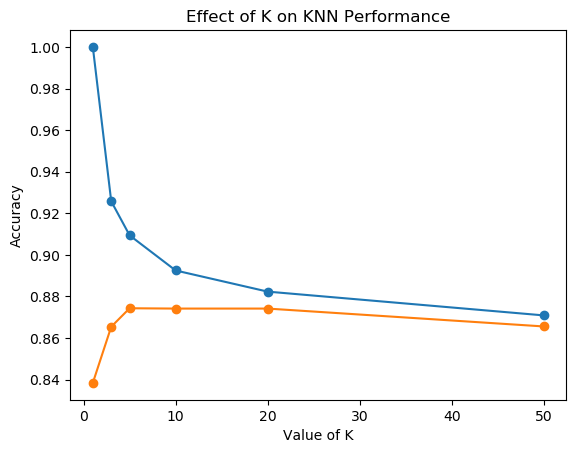

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(results_df.index, results_df["Train Accuracy"], marker='o')
plt.plot(results_df.index, results_df["Test Accuracy"], marker='o')
plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("Effect of K on KNN Performance")
plt.show()


In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_range = range(1, 21)
test_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    test_accuracies.append(accuracy_score(y_test, y_pred))

best_k = k_range[test_accuracies.index(max(test_accuracies))]
best_k, max(test_accuracies)


(17, 0.8763234617155132)

In [36]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=17)

In [37]:
y_test_pred = knn_best.predict(X_test)
y_test_pred[:10]


array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0], dtype=int64)

In [38]:
sample_customer = X_test[0].reshape(1, -1)

for k in [1, 3, 5, 10, best_k]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    prediction = knn.predict(sample_customer)
    print(f"K = {k} → Predicted Risk:", "High Risk" if prediction[0] == 1 else "Low Risk")


K = 1 → Predicted Risk: Low Risk
K = 3 → Predicted Risk: Low Risk
K = 5 → Predicted Risk: Low Risk
K = 10 → Predicted Risk: Low Risk
K = 17 → Predicted Risk: Low Risk


In [39]:
accuracy = accuracy_score(y_test, y_test_pred)
accuracy


0.8763234617155132

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
cm


array([[4889,  183],
       [ 623,  822]], dtype=int64)

In [41]:
tn, fp, fn, tp = cm.ravel()

print("True Positives (High Risk correctly identified):", tp)
print("False Negatives (High Risk misclassified as Low Risk):", fn)
print("True Negatives (Low Risk correctly identified):", tn)
print("False Positives (Low Risk misclassified as High Risk):", fp)


True Positives (High Risk correctly identified): 822
False Negatives (High Risk misclassified as Low Risk): 623
True Negatives (Low Risk correctly identified): 4889
False Positives (Low Risk misclassified as High Risk): 183
